<a href="https://colab.research.google.com/github/shristea7/College-Dump/blob/main/AI_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem Statement: The treasure is hidden in a grid, and each cell has a heuristic value
representing its "closeness" to the treasure. Implement Best-First Search to locate the treasure. Tasks:
 Use Manhattan distance as a heuristic.  Implement the algorithm to always move to the most promising cell first (minimum heuristic
value).  Analyze how heuristic choice affects performance by comparing to BFS, DFS

In [ ]:
import random
import heapq
from collections import deque
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def generate_grid(rows, cols, obstacle_prob=0.25):
    grid = [['.' for _ in range(cols)] for _ in range(rows)]
    for i in range(rows):
        for j in range(cols):
            if random.random() < obstacle_prob:
                grid[i][j] = '#'
    start = (random.randint(0, rows-1), random.randint(0, cols-1))
    goal = (random.randint(0, rows-1), random.randint(0, cols-1))
    while start == goal or grid[start[0]][start[1]] == '#' or grid[goal[0]][goal[1]] == '#':
        start = (random.randint(0, rows-1), random.randint(0, cols-1))
        goal = (random.randint(0, rows-1), random.randint(0, cols-1))
    grid[start[0]][start[1]] = 'S'
    grid[goal[0]][goal[1]] = 'T'
    return grid, start, goal


In [ ]:
def print_grid(grid):
    for row in grid:
        print(" ".join(row))


In [ ]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])
def get_neighbors(r, c):
    for dr, dc in [(1,0), (-1,0), (0,1), (0,-1)]:
        nr, nc = r + dr, c + dc
        if 0 <= nr < ROWS and 0 <= nc < COLS and grid[nr][nc] != '#':
            yield (nr, nc)


In [ ]:
def best_first_search(start, goal):
    pq = []  # priority queue
    heapq.heappush(pq, (manhattan(start, goal), start))

    visited = set()
    parent = {start: None}
    explored_order = []

    while pq:
        _, current = heapq.heappop(pq)
        explored_order.append(current)

        if current == goal:
            break

        visited.add(current)

        for neighbor in get_neighbors(current[0], current[1]):
            if neighbor not in visited and neighbor not in [pos for _, pos in pq]:
                parent[neighbor] = current
                heapq.heappush(pq, (manhattan(neighbor, goal), neighbor))

    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = parent.get(node)
    path.reverse()

    return path, explored_order


In [ ]:
def bfs_visual(start, goal):
    queue = deque([start])
    parent = {start: None}
    explored_order = []
    while queue:
        current = queue.popleft()
        explored_order.append(current)
        if current == goal:
            break
        for neighbor in get_neighbors(*current):
            if neighbor not in parent:
                parent[neighbor] = current
                queue.append(neighbor)
    path = []
    node = goal
    while node:
        path.append(node)
        node = parent.get(node)
    path.reverse()
    return path, explored_order


In [ ]:
def dfs_visual(start, goal):
    stack = [start]
    parent = {start: None}
    explored_order = []
    while stack:
        current = stack.pop()
        explored_order.append(current)
        if current == goal:
            break
        for neighbor in get_neighbors(*current):
             if neighbor not in parent:
                parent[neighbor] = current
                stack.append(neighbor)
    path = []
    node = goal
    while node:
        path.append(node)
        node = parent.get(node)
    path.reverse()
    return path, explored_order


In [ ]:
def plot_maze_solution(grid, explored, path, start, goal, title):
    rows = len(grid)
    cols = len(grid[0])
    maze = np.zeros((rows, cols))
    for r in range(rows):
        for c in range(cols):
            if grid[r][c] == '#':
                maze[r, c] = 1
    fig, ax = plt.subplots(figsize=(6,6))
    ax.imshow(maze, cmap='gray_r')
    ex_r = [r for r, c in explored]
    ex_c = [c for r, c in explored]
    ax.scatter(ex_c, ex_r, s=25)
    path_r = [r for r, c in path]
    path_c = [c for r, c in path]
    ax.scatter(path_c, path_r, s=40)
    ax.scatter(start[1], start[0], s=90)
    ax.scatter(goal[1], goal[0], s=90)
    ax.set_xticks(range(cols))
    ax.set_yticks(range(rows))
    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which='minor')
    ax.set_xlim(-0.5, cols - 0.5)
    ax.set_ylim(rows - 0.5, -0.5)
    ax.set_title(title)
    plt.show()


In [ ]:
def plot_maze_solutions(grid, explored, path, start, goal, title):
    rows = len(grid)
    cols = len(grid[0])
    maze = np.zeros((rows, cols))

    for r in range(rows):
        for c in range(cols):
            if grid[r][c] == '#':
                maze[r, c] = 1

    fig, ax = plt.subplots(figsize=(6,6))
    ax.imshow(maze, cmap='gray_r')

    ex_r = [r for r, c in explored]
    ex_c = [c for r, c in explored]
    ax.scatter(ex_c, ex_r, s=25, label='Explored')

    path_r = [r for r, c in path]
    path_c = [c for r, c in path]
    ax.scatter(path_c, path_r, s=40, label='Path')

    ax.scatter(start[1], start[0], s=90, label='Start', c='green')
    ax.scatter(goal[1], goal[0], s=90, label='Goal', c='red')

    for r in range(rows):
        for c in range(cols):
            if grid[r][c] != '#':
                h = manhattan((r, c), goal)
                ax.text(c, r, str(h), color='black', ha='center', va='center', fontsize=8)

    ax.set_xticks(range(cols))
    ax.set_yticks(range(rows))
    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which='minor')
    ax.set_xlim(-0.5, cols - 0.5)
    ax.set_ylim(rows - 0.5, -0.5)
    ax.set_title(title)
    plt.show()


Enter number of rows: 12
Enter number of columns: 12
Generated Grid:
. . # . . . . # # . . .
# # . . # . . # # # . #
. . . # . T . . . # . .
# . . # # . . # # . # .
. . . . . . # . # # # .
# . . . . . . . . . . .
. # # # # . . # . . . .
. . # . . . . . . . # .
# . . . . . . # S . . #
. . . . . . . . . # . .
. # # . . . . . . # . .
. # # # # . . # . . . .


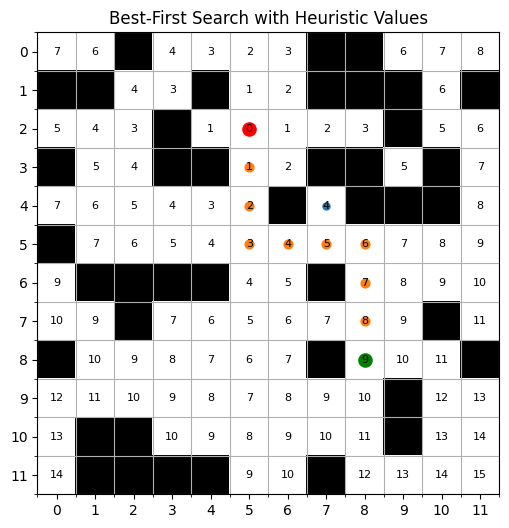

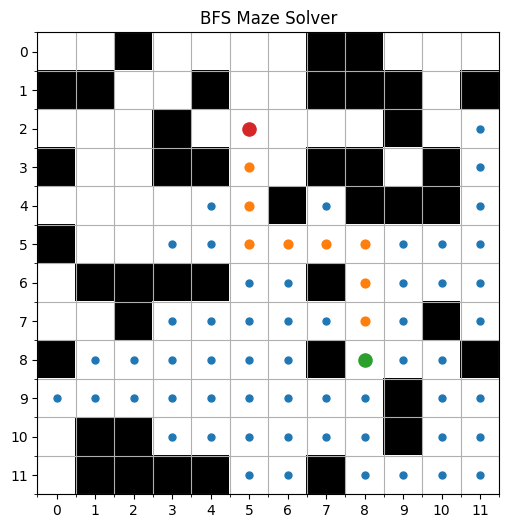

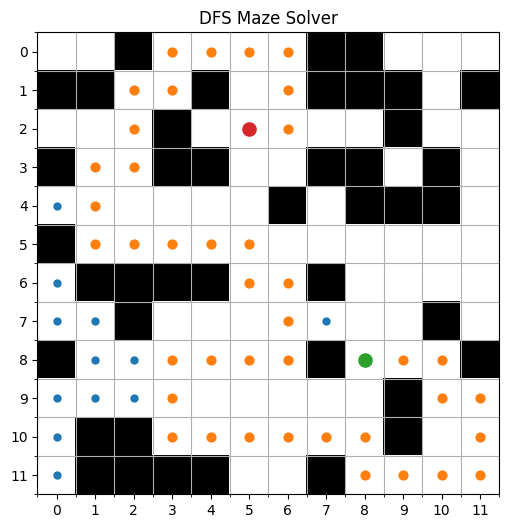

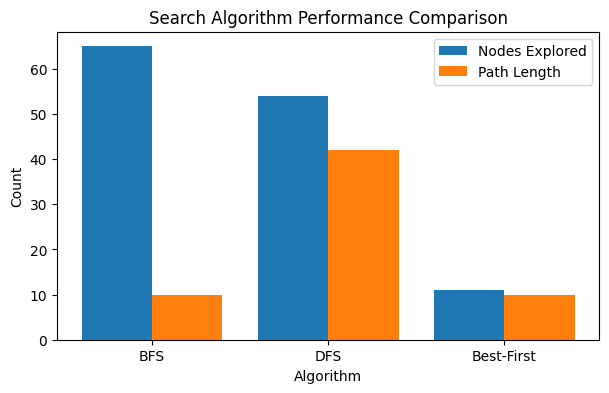

In [ ]:
ROWS = int(input("Enter number of rows: "))
COLS = int(input("Enter number of columns: "))
grid, start, goal = generate_grid(ROWS, COLS)
print("Generated Grid:")
print_grid(grid)
bfs_path, bfs_explored = bfs_visual(start, goal)
dfs_path, dfs_explored = dfs_visual(start, goal)
best_path, best_explored = best_first_search(start, goal)
plot_maze_solutions(grid, best_explored, best_path, start, goal, "Best-First Search with Heuristic Values")
plot_maze_solution(grid, bfs_explored, bfs_path, start, goal, "BFS Maze Solver")
plot_maze_solution(grid, dfs_explored, dfs_path, start, goal, "DFS Maze Solver")
algorithms = ['BFS', 'DFS', 'Best-First']
explored_nodes = [len(bfs_explored),len(dfs_explored),len(best_explored)]
path_lengths = [len(bfs_path),len(dfs_path),len(best_path)]
x = range(len(algorithms))
plt.figure(figsize=(7,4))
plt.bar(x, explored_nodes, width=0.4, label='Nodes Explored')
plt.bar([i + 0.4 for i in x], path_lengths, width=0.4, label='Path Length')
plt.xticks([i + 0.2 for i in x], algorithms)
plt.xlabel("Algorithm")
plt.ylabel("Count")
plt.title("Search Algorithm Performance Comparison")
plt.legend()
plt.show()
